# Shapes, broadcasting, and dtypes

Runnable locally on CPU or on a Cloud TPU VM.

- Apply the trailing-dimension broadcasting rule before execution.
- Distinguish feature-wise and observation-wise offsets with explicit singleton axes.
- Find a silent pairwise-residual bug using values and shape checks.
- State dtype and precision assumptions for numerical experiments.

Your code runs, but has it added the bias to the right axis? This is a common array puzzle: a legal operation can still answer the wrong question. We’ll use small tables to see exactly which values combine, then catch a broadcasting mistake that turns one error per example into a whole matrix of errors.

## The idea

Before adding or subtracting arrays, name what each axis represents. Broadcasting aligns dimensions from the right and reuses singleton dimensions. A legal broadcast can still answer the wrong question, especially when a final mean hides the resulting shape.

## Catch the scalar that hides a shape mistake

Take predictions $[1,3]$ and matching targets $[1,3]$. The intended residuals are $[0,0]$, so mean squared error is zero. If the targets are stored as a column, subtraction instead compares each target against both predictions. The residual matrix has entries $0,2,-2,0$, and its mean squared error is $2$.

Both calculations return a scalar after averaging. Looking only at the final loss, or checking that autodiff can differentiate it, will not expose the problem. Inspect the residual shape before reducing it and compare against a known aligned example.

This is also why a reshape should express a data contract. A singleton feature axis can mean one offset per observation; a singleton observation axis can mean one offset per feature. They are different operations even when an unlucky square fixture makes both expressions run.

### Align axes before reducing

**Predict:** Why is checking that the loss is scalar insufficient?

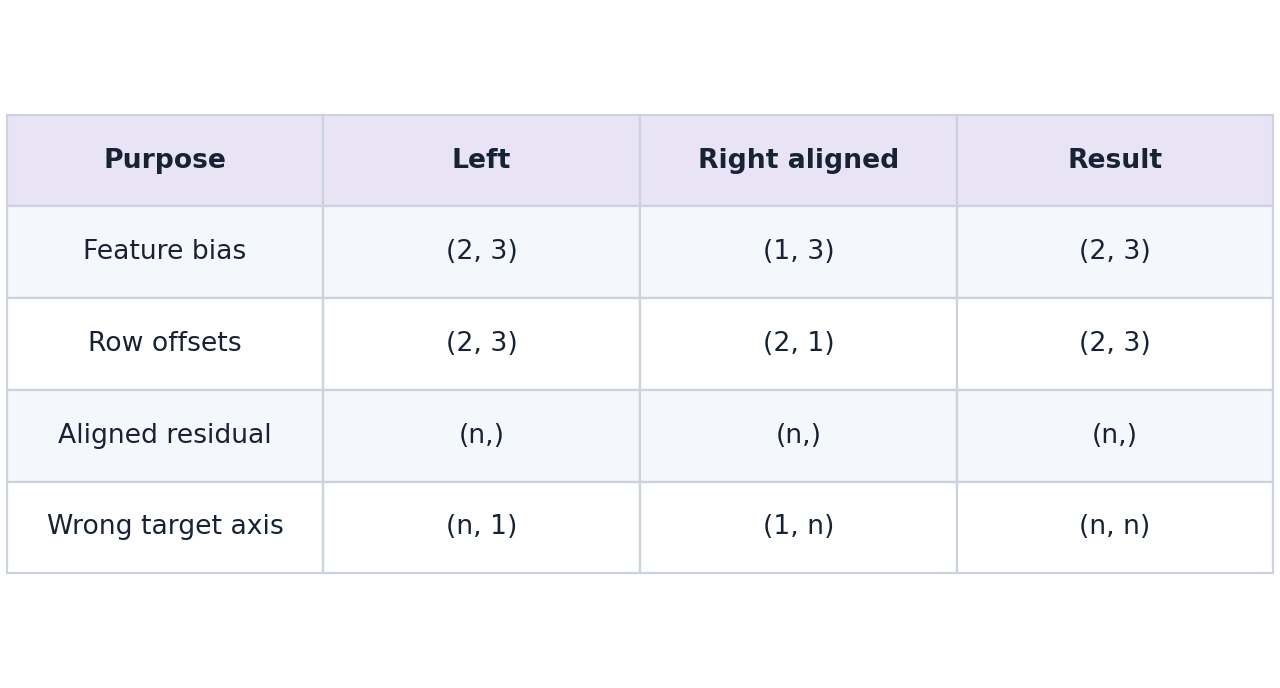

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Feature bias reuses a vector across observations; row offsets reuse each scalar across features. The final row creates all-pairs residuals. A mean would hide the unwanted $(n,n)$ intermediate. Each row describes a different shape contract.

### Pause and reason

Why is checking that the loss is scalar insufficient?

<details><summary>Compare your reasoning</summary>

A mean can reduce an incorrectly broadcast matrix to a scalar. Check prediction/target alignment and an independently known loss before reduction, not only the final result's rank.

</details>

## Work the shape rule one dimension at a time

Align $(2, 3)$ and $(3,)$ as $(2, 3)$ and $(1, 3)$. The trailing $3$ matches, and the leading $1$ can broadcast to $2$. By contrast, $(2,)$ aligns as $(1, 2)$: trailing $2$ conflicts with $3$. That expression cannot add one scalar per row without another axis.

Represent row offsets as $(2, 1)$. The leading $2$ matches observations and the trailing $1$ broadcasts over the three features. A singleton axis is a statement about how data should be reused, not a random reshape to silence an exception.

```text
feature bias: (2,3) + (1,3) → (2,3)
row offset:  (2,3) + (2,1) → (2,3)
wrong row offset: (2,3) + (2,) → incompatible
```

## Do not test axes with only square arrays

If a batch happens to have $B=D$, a vector of length $B$ can accidentally fit as a feature vector. The expression succeeds while doing the wrong calculation. A test with two observations and three features forces those meanings apart.

Use distinguishable values, such as feature bias $[10, 20, 30]$ and row offsets $[100, 200]$. Then inspect at least two rows and columns. Shape checks alone do not detect every semantically wrong operation; the values need a known reference too.

## A legal broadcast can change your loss

Predictions with shape $(B,)$ and targets with shape $(B, 1)$ broadcast to $(B, B)$. Each row then compares one target to every prediction. A mean over that matrix is a scalar, so a later gradient transform can accept it even though the objective is wrong.

For predictions $[1, 3, 5]$ and matching targets, the intended residual vector is all zero. A column target produces rows $[0, 2, 4]$, $[-2, 0, 2]$, $[-4, -2, 0]$, and a positive mean-squared error. Independent expected values expose the bug immediately. Validate prediction/target shape equality at the boundary where aligned examples are required.

```text
(B,) − (B,1) → (B,B)
Intended aligned-example contract: prediction.shape == target.shape
```

## Shape and dtype are separate contracts

Shape says how values are arranged; dtype says how each value is represented. Use explicit float32 inputs for this course experiment so the precision assumption is visible. Default JAX precision and X64 configuration can differ from expectations brought from a NumPy workflow.

A correctly shaped float32 calculation can still lose a small change at large magnitude. That is numerical representation, not an axis error. Record both shape and dtype in debugging output, and choose comparisons appropriate to their scale. Enabling a different dtype is not a substitute for correcting a broadcast.

## Make boundary checks before reducing

A reduction often hides shape information. Before averaging residuals, check whether the array is the expected $(B,)$ vector or an unintended matrix. Likewise, check that feature statistics have one entry per feature and that row offsets have the observation dimension.

These checks belong at meaningful boundaries, rather than after every elementary addition. A descriptive failure before a loss is calculated is more useful than a plausible scalar whose semantics have already been lost.

## Run the example

In [1]:
# Shapes, broadcasting, and dtypes: Before adding or subtracting arrays, name what each axis represents.
# Import jax.numpy for this computation.
import jax.numpy as jnp
# Initialize array `batch` with explicit values and shape.
batch = jnp.array([[1., 2., 3.], [4., 5., 6.]], dtype=jnp.float32)
# Initialize array `bias` with explicit values and shape.
bias = jnp.array([10., 20., 30.], dtype=jnp.float32)
# Evaluate `y` from the current inputs and state.
y = batch + bias
# Print the observed values to compare against the expected result.
print(y)
# Print diagnostic summary of the computed outputs.
print("Shape:", y.shape, "dtype:", y.dtype)
# Verify that the output tensor shape matches our prediction.
assert y.shape == (2, 3)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(y[1], jnp.array([14., 25., 36.]))

[[11. 22. 33.]
 [14. 25. 36.]]
Shape: (2, 3) dtype: float32


Expected: Rows: $[11., 22., 33.]$ and $[14., 25., 36.]$; shape $(2, 3)$, dtype float32.

## Broadcasting repeats the bias across rows

Predict: Why are both rows of the difference equal to $(10,20,30)$?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
# Compute figure data for: Broadcasting repeats the bias across rows
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'heatmap', 'values': (y - batch).tolist(), 'rows': ['observation 0', 'observation 1'], 'columns': ['feature 0', 'feature 1', 'feature 2'], 'unit': 'added bias'}

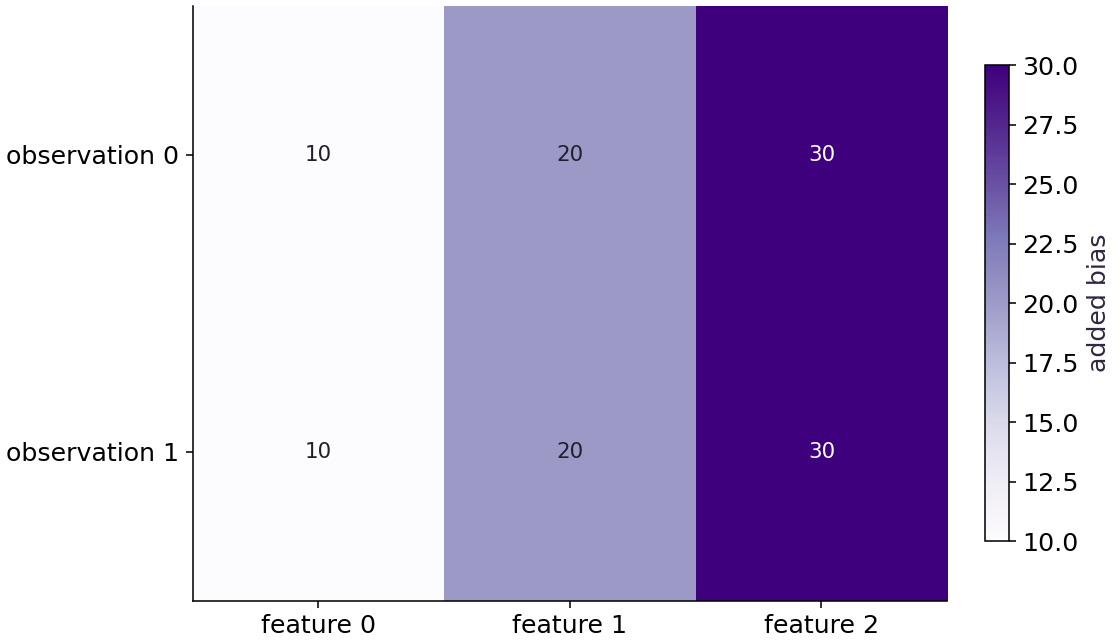

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

This heatmap shows the added amount, computed as the output minus the input batch. It does not show the final output array. Rows are observations and columns are features; the cell values and color bar measure added bias.

Both rows read $(10,20,30)$. The repeated vertical bands show that feature $0$ receives $10$ in every observation, feature $1$ receives $20$, and feature $2$ receives $30$.

### Connect it to the computation

The bias has shape $(3,)$, which aligns with the last axis of the $(2,3)$ batch. Broadcasting applies the same feature-wise addition to both rows. For example, the input $(1,2,3)$ becomes $(11,22,33)$, while $(4,5,6)$ becomes $(14,25,36)$.

Identical rows in this picture mean identical additions, not identical predictions. If you intended a different offset for each observation, you would need a row-wise bias with a compatible shape, such as $(2,1)$; this figure would then have horizontal bands.

## Make the pairwise bug visible

Predict: Matching predictions and targets should have zero loss. Predict the matrix created by a column target and its mean-square value.

In [4]:
# Experiment — Make the pairwise bug visible: The final result is scalar in both cases.
# Initialize array `predictions` with explicit values and shape.
predictions = jnp.array([1., 3., 5.])
# Initialize array `targets` with explicit values and shape.
targets = jnp.array([1., 3., 5.])
# Evaluate `correct_residuals` from the current inputs and state.
correct_residuals = predictions - targets
# Evaluate `pairwise_residuals` from the current inputs and state.
pairwise_residuals = predictions - targets[:, None]
# Print the observed values to compare against the expected result.
print("aligned residuals:", correct_residuals)
# Print diagnostic summary of the computed outputs.
print("pairwise residuals:", pairwise_residuals)
# Verify that the output tensor shape matches our prediction.
assert correct_residuals.shape == (3,)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert pairwise_residuals.shape == (3, 3)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.mean(correct_residuals ** 2), 0.)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.mean(pairwise_residuals ** 2), 16. / 3.)

aligned residuals: [0. 0. 0.]
pairwise residuals: [[ 0.  2.  4.]
 [-2.  0.  2.]
 [-4. -2.  0.]]


Expected: The incorrect broadcast produces shape $(3, 3)$ and loss $16/3$, despite perfect aligned predictions.

The final result is scalar in both cases. Checking only the final loss shape would miss this objective bug.

## Observe a precision limit separately

Predict: Does float32 preserve adding $1$ to $100$,$000$,$000$? Is the shape relevant to that result?

In [5]:
# Experiment — Observe a precision limit separately: This scalar example isolates precision from broadcasting.
# Initialize array `large` with explicit values and shape.
large = jnp.array(100_000_000., dtype=jnp.float32)
# Print the observed values to compare against the expected result.
print("float32 large + 1 − large:", float((large + 1.) - large))
# Verify contract: `float(large + 1.0 - large) == 0.0`.
assert float((large + 1.) - large) == 0.
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert large.shape == ()

float32 large + 1 − large: 0.0


Expected: The recorded difference is zero because the representable spacing at this magnitude exceeds $1$.

This scalar example isolates precision from broadcasting. Autodiff and compilation do not make every arithmetic operation exact.

## Your exercise

Add a different scalar offset to each row using offsets $[100., 200.]$. Make its shape explicit.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `offsets` with explicit values and shape.
2. Evaluate `z` from the current inputs and state.
3. Verify that the output tensor shape matches our prediction.
4. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Add a different scalar offset to each row using offsets [100., 200.].
# Initialize array `offsets` with explicit values and shape.
offsets = jnp.array(...)  # TODO: compute offsets
# Evaluate `z` from the current inputs and state.
z = ...  # TODO: compute z
# Verify that the output tensor shape matches our prediction.
assert offsets.shape  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(z, jnp.array([[101.,102.,103.],[204.,205.,206.]]))  # TODO: complete assertion check
```

In [6]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Add a different scalar offset to each row using offsets [100., 200.].
# Initialize array `offsets` with explicit values and shape.
# offsets = jnp.array(...)  # TODO: compute offsets
# Evaluate `z` from the current inputs and state.
# z = ...  # TODO: compute z
# Verify that the output tensor shape matches our prediction.
# assert offsets.shape  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(z, jnp.array([[101.,102.,103.],[204.,205.,206.]]))  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [7]:
# Exercise solution: Add a different scalar offset to each row using offsets [100., 200.].
# Initialize array `offsets` with explicit values and shape.
offsets = jnp.array([100., 200.])[:, None]
# Evaluate `z` from the current inputs and state.
z = batch + offsets
# Verify that the output tensor shape matches our prediction.
assert offsets.shape == (2, 1)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(z, jnp.array([[101.,102.,103.],[204.,205.,206.]]))

## Use both kinds of offsets together · Practice

Add the feature bias and row offsets to the original batch. Derive every row before running, then check with an explicitly constructed array.

Hint: Use bias shape $(3,)$ and offsets shape $(2, 1)$. Do not swap their semantic roles.

### How to write: Use both kinds of offsets together — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `combined` with explicit values and shape.
2. Verify that the output tensor shape matches our prediction.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Use both kinds of offsets together (Practice): The first row receives 100 in every feature and the second...
# Initialize array `combined` with explicit values and shape.
combined = ...  # TODO: compute combined
# Verify that the output tensor shape matches our prediction.
assert combined.shape  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(combined, jnp.array([[111., 122., 133.], [214., 225., 236.]]))  # TODO: complete assertion check
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Use both kinds of offsets together (Practice): The first row receives 100 in every feature and the second...
# Initialize array `combined` with explicit values and shape.
# combined = ...  # TODO: compute combined
# Verify that the output tensor shape matches our prediction.
# assert combined.shape  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(combined, jnp.array([[111., 122., 133.], [214., 225., 236.]]))  # TODO: complete assertion check

## Reference reasoning

The first row receives $100$ in every feature and the second receives $200$, while the feature bias differs by column.

In [9]:
# Use both kinds of offsets together (Practice): The first row receives 100 in every feature and the second...
# Initialize array `combined` with explicit values and shape.
combined = batch + bias + jnp.array([100., 200.])[:, None]
# Verify that the output tensor shape matches our prediction.
assert combined.shape == (2, 3)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(combined, jnp.array([[111., 122., 133.], [214., 225., 236.]]))

## Reject an aligned-loss contract violation · Challenge

Write an MSE function that requires prediction and target shapes to match. Test zero loss for matching vectors and rejection of a column target. Explain why an automatic reshape might hide a data-ordering problem.

Hint: Raise a descriptive ValueError before subtracting. The check is based on shape metadata, not array truth values.

### How to write: Reject an aligned-loss contract violation — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
2. Return `jnp.mean((prediction - target) ** 2)` to the caller.
3. Verify that the numerical values match the expected reference within tolerance.
4. Run the boundary check and catch the expected exception:

**Starter code scaffold (fill in the TODOs):**

```python
# Reject an aligned-loss contract violation (Challenge): Fix shapes at the data/model interface according to the...
def aligned_mse(prediction, target):
    # Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
    if prediction.shape != target.shape:
        raise ValueError("aligned prediction and target shapes must match")
    # Return `jnp.mean((prediction - target) ** 2)` to the caller.
    return ...  # TODO: return computed result
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(aligned_mse(predictions, targets), 0.)  # TODO: complete assertion check
# Run the boundary check and catch the expected exception:
try:
    aligned_mse(predictions, targets[:, None])
except ValueError:
    pass
else:
    raise AssertionError("Column targets must be rejected")
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject an aligned-loss contract violation (Challenge): Fix shapes at the data/model interface according to the...
# def aligned_mse(prediction, target):
    # Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
#     if prediction.shape != target.shape:
#         raise ValueError("aligned prediction and target shapes must match")
    # Return `jnp.mean((prediction - target) ** 2)` to the caller.
#     return ...  # TODO: return computed result
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(aligned_mse(predictions, targets), 0.)  # TODO: complete assertion check
# Run the boundary check and catch the expected exception:
# try:
#     aligned_mse(predictions, targets[:, None])
# except ValueError:
#     pass
# else:
#     raise AssertionError("Column targets must be rejected")

## Reference reasoning

Fix shapes at the data/model interface according to the intended example order. Blindly reshaping inside a loss can conceal mismatched semantics.

In [11]:
# Reject an aligned-loss contract violation (Challenge): Fix shapes at the data/model interface according to the...
def aligned_mse(prediction, target):
    # Guard input contract (`prediction.shape != target.shape`) and fail fast if violated.
    if prediction.shape != target.shape:
        raise ValueError("aligned prediction and target shapes must match")
    # Return `jnp.mean((prediction - target) ** 2)` to the caller.
    return jnp.mean((prediction - target) ** 2)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(aligned_mse(predictions, targets), 0.)
# Run the boundary check and catch the expected exception:
try:
    aligned_mse(predictions, targets[:, None])
except ValueError:
    pass
else:
    raise AssertionError("Column targets must be rejected")

## Checkpoint

Which offset shape adds one scalar to each row of a $(2, 3)$ batch?

1. $(2,)$
2. $(2, 1)$
3. $(3, 2)$

## Diagnose

When broadcasting fails, align trailing dimensions on paper. When it succeeds with a surprising loss, inspect the residual shape before reduction and compare with hand-derived values. When a small change disappears, inspect dtype and magnitude. Use asymmetric shape tests so accidentally equal dimension sizes do not conceal a wrong axis.

## Evidence

Keep an axis sketch, asymmetric offset checks, aligned-versus-pairwise residual arrays, a rejected shape mismatch, and the float32 precision observation. Explain the intended residual contract.

## Carry forward

- Broadcasting compatibility does not imply semantic correctness.
- A singleton axis declares reuse along a particular dimension.
- Prediction/target mismatch can silently create all-pairs residuals.
- Check dtype separately from shape and record numerical scale.

## Primary references

- [NumPy: broadcasting rules](https://numpy.org/doc/stable/user/basics.broadcasting.html)
- [JAX: default dtypes and X64](https://docs.jax.dev/en/latest/default_dtypes.html)